# Step 1: Download the Dataset

In [ ]:
!pip install -q kaggle


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
import os
!pip install pandas nltk
import pandas as pd
import nltk

!kaggle datasets download -d yelp-dataset/yelp-dataset


Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other


2. Extract the Dataset

In [ ]:
# Unzip the dataset
!unzip yelp-dataset.zip -d yelp_dataset


Archive:  yelp-dataset.zip
  inflating: yelp_dataset/Dataset_User_Agreement.pdf  
  inflating: yelp_dataset/yelp_academic_dataset_business.json  
  inflating: yelp_dataset/yelp_academic_dataset_checkin.json  
  inflating: yelp_dataset/yelp_academic_dataset_review.json  
  inflating: yelp_dataset/yelp_academic_dataset_tip.json  
  inflating: yelp_dataset/yelp_academic_dataset_user.json  


In [ ]:
!ls yelp_dataset


Dataset_User_Agreement.pdf	     yelp_academic_dataset_review.json
yelp_academic_dataset_business.json  yelp_academic_dataset_tip.json
yelp_academic_dataset_checkin.json   yelp_academic_dataset_user.json


# Step 2: Initial Data Loading

In [ ]:
import pandas as pd

business_df = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_business.json', lines=True, nrows=100000)
review_df = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_review.json', lines=True, nrows=100000)
user_df = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_user.json', lines=True, nrows=100000)
checkin_df = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_checkin.json', lines=True, nrows=100000)
tip_df = pd.read_json('/content/yelp_dataset/yelp_academic_dataset_tip.json', lines=True, nrows=100000)

print("Shapes of Loaded DataFrames:")
print("Business:", business_df.shape)
print("Review:", review_df.shape)
print("User:", user_df.shape)
print("Checkin:", checkin_df.shape)
print("Tip:", tip_df.shape)


Shapes of Loaded DataFrames:
Business: (100000, 14)
Review: (100000, 9)
User: (100000, 22)
Checkin: (100000, 2)
Tip: (100000, 5)


# Step 3: Initial Inspection and Quality Checks


1. Check Structure and Data Types:

In [ ]:
print("Business DF Info:\n", business_df.info())
print("Review DF Info:\n", review_df.info())
print("User DF Info:\n", user_df.info())
print("Checkin DF Info:\n", checkin_df.info())
print("Tip DF Info:\n", tip_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   100000 non-null  object 
 1   name          100000 non-null  object 
 2   address       100000 non-null  object 
 3   city          100000 non-null  object 
 4   state         100000 non-null  object 
 5   postal_code   100000 non-null  object 
 6   latitude      100000 non-null  float64
 7   longitude     100000 non-null  float64
 8   stars         100000 non-null  float64
 9   review_count  100000 non-null  int64  
 10  is_open       100000 non-null  int64  
 11  attributes    90915 non-null   object 
 12  categories    99931 non-null   object 
 13  hours         84564 non-null   object 
dtypes: float64(3), int64(2), object(9)
memory usage: 10.7+ MB
Business DF Info:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 

2. Preview Data:

In [ ]:
print(business_df.head())
print(review_df.head())


              business_id                      name  \
0  Pns2l4eNsfO8kk83dixA6A  Abby Rappoport, LAC, CMQ   
1  mpf3x-BjTdTEA3yCZrAYPw             The UPS Store   
2  tUFrWirKiKi_TAnsVWINQQ                    Target   
3  MTSW4McQd7CbVtyjqoe9mw        St Honore Pastries   
4  mWMc6_wTdE0EUBKIGXDVfA  Perkiomen Valley Brewery   

                           address           city state postal_code  \
0           1616 Chapala St, Ste 2  Santa Barbara    CA       93101   
1  87 Grasso Plaza Shopping Center         Affton    MO       63123   
2             5255 E Broadway Blvd         Tucson    AZ       85711   
3                      935 Race St   Philadelphia    PA       19107   
4                    101 Walnut St     Green Lane    PA       18054   

    latitude   longitude  stars  review_count  is_open  \
0  34.426679 -119.711197    5.0             7        0   
1  38.551126  -90.335695    3.0            15        1   
2  32.223236 -110.880452    3.5            22        0   
3  39.9555

3. Check for Missing Values and Duplicates:

In [ ]:
print("Missing values in Review DF:\n", review_df.isnull().sum())
print("Missing values in Business DF:\n", business_df.isnull().sum())
print("Missing values in User DF:\n", user_df.isnull().sum())
print("Missing values in Checkin DF:\n", checkin_df.isnull().sum())
print("Missing values in Tip DF:\n", tip_df.isnull().sum())


print("Duplicate review_ids:", review_df.duplicated('review_id').sum())
print("Duplicate business_ids:", business_df.duplicated('business_id').sum())
print("Duplicate user_ids:", user_df.duplicated('user_id').sum())
# For checkin and tip, duplicates may not be critical in the same way, but we ensure no exact duplicates:
print("Checkin duplicates:", checkin_df.duplicated().sum())
print("Tip duplicates:", tip_df.duplicated().sum())



Missing values in Review DF:
 review_id      0
user_id        0
business_id    0
stars          0
useful         0
funny          0
cool           0
text           0
date           0
dtype: int64
Missing values in Business DF:
 business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes       9085
categories         69
hours           15436
dtype: int64
Missing values in User DF:
 user_id               0
name                  0
review_count          0
yelping_since         0
useful                0
funny                 0
cool                  0
elite                 0
friends               0
fans                  0
average_stars         0
compliment_hot        0
compliment_more       0
compliment_profile    0
compliment_cute       0
compliment_list       0
compliment_note       0
compliment_plai

# Step 4: Data Cleaning

1. Remove Duplicates:

In [ ]:
review_df.drop_duplicates(subset='review_id', inplace=True)
business_df.drop_duplicates(subset='business_id', inplace=True)
user_df.drop_duplicates(subset='user_id', inplace=True)
checkin_df.drop_duplicates(inplace=True)
tip_df.drop_duplicates(inplace=True)


2. Handle Missing Values:

In [ ]:
review_df = review_df.dropna(subset=['text'])


# Step 5: Text Preprocessing for Reviews

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]  # Remove stopwords and lemmatize
    return ' '.join(words)

review_df['cleaned_text'] = review_df['text'].apply(preprocess_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# Step 6: Integrate Multiple Data Sources

1. Merge Reviews with Business Data:

In [ ]:
merged_df = pd.merge(review_df, business_df, on='business_id', how='left')


2. Add User-Level Features: If you want user-level features like average rating given by a user:

In [ ]:
merged_df = pd.merge(merged_df, user_df[['user_id', 'average_stars', 'review_count']], on='user_id', how='left')


3. Incorporate Checkin Data: Aggregate checkin counts per business:

In [ ]:
checkin_counts = checkin_df.groupby('business_id').size().reset_index(name='checkin_count')
merged_df = pd.merge(merged_df, checkin_counts, on='business_id', how='left')
merged_df['checkin_count'] = merged_df['checkin_count'].fillna(0)


4. Incorporate Tip Data: Aggregate tip counts per business:

In [ ]:
tip_counts = tip_df.groupby('business_id').size().reset_index(name='tip_count')
merged_df = pd.merge(merged_df, tip_counts, on='business_id', how='left')
merged_df['tip_count'] = merged_df['tip_count'].fillna(0)


In [ ]:
print(merged_df.columns)


Index(['review_id', 'user_id', 'business_id', 'stars_x', 'useful', 'funny',
       'cool', 'text', 'date', 'cleaned_text', 'name', 'address', 'city',
       'state', 'postal_code', 'latitude', 'longitude', 'stars_y',
       'review_count_x', 'is_open', 'attributes', 'categories', 'hours',
       'average_stars', 'review_count_y', 'checkin_count', 'tip_count'],
      dtype='object')


In [ ]:
merged_df.rename(columns={
    'stars_x': 'stars',           # user given rating in that review
    'review_count_y': 'review_count'  # total reviews by the user
}, inplace=True)


# Step 7: Feature Selection & Saving the Preprocessed Data

1. Select Relevant Columns: Choose columns needed for sentiment and retention modeling:

In [ ]:
final_df = merged_df[['review_id', 'user_id', 'business_id', 'cleaned_text', 'stars', 'categories',
                      'average_stars', 'review_count', 'checkin_count', 'tip_count']]

2. Save the Processed Dataset:

In [ ]:
final_df.to_csv('preprocessed_data.csv', index=False)


# Module 3





In [ ]:
pip install pandas matplotlib seaborn nltk


Step 1: Load the Preprocessed Dataset

In [ ]:
data = pd.read_csv('preprocessed_data.csv')
print("Dataset Loaded:")
print("Shape:", data.shape)
print(data.head())


Dataset Loaded:
Shape: (100000, 10)
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   

                                        cleaned_text  stars  \
0  decide eat aware going take 2 hour beginning e...      3   
1  ive taken lot spin class year nothing compare ...      5   
2  family diner buffet eclectic assortment large ...      3   
3  wow yummy different delicious favorite lamb cu...      5   
4  cute interior owner gave u tour upcoming patio...      4   

                                          categories  average_stars  \
0  Restaurants, Breakfast & Brunch, Food, Juice B..

Step 2: Check for Missing Values and Basic Stats

In [ ]:
# Check for missing values
print("Missing Values:\n", data.isnull().sum())

# Display basic statistics
print("Basic Statistics:\n", data.describe(include='all'))


Missing Values:
 review_id            0
user_id              0
business_id          0
cleaned_text         2
stars                0
categories           4
average_stars    41644
review_count     41644
checkin_count        0
tip_count            0
dtype: int64
Basic Statistics:
                      review_id                 user_id  \
count                   100000                  100000   
unique                  100000                   79345   
top     gHEj_BQhIj6i_82--qmWWw  _BcWyKQL16ndpBdggh2kNA   
freq                         1                      65   
mean                       NaN                     NaN   
std                        NaN                     NaN   
min                        NaN                     NaN   
25%                        NaN                     NaN   
50%                        NaN                     NaN   
75%                        NaN                     NaN   
max                        NaN                     NaN   

                   busin

Step 3: Distribution of Ratings (Stars)

<ipython-input-24-21275d0abd02>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='stars', palette='viridis')


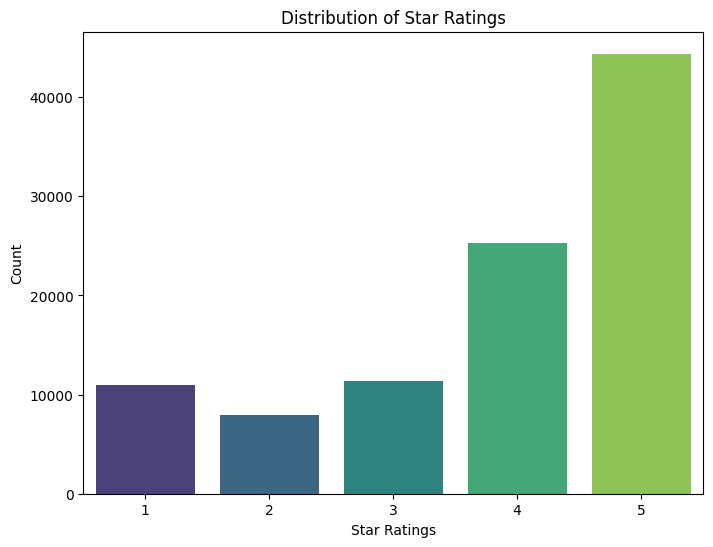

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='stars', palette='viridis')
plt.title('Distribution of Star Ratings')
plt.xlabel('Star Ratings')
plt.ylabel('Count')
plt.show()


Step 4: Analyze Business Categories

<ipython-input-25-00987d011259>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_df, x='Count', y='Category', palette='viridis')


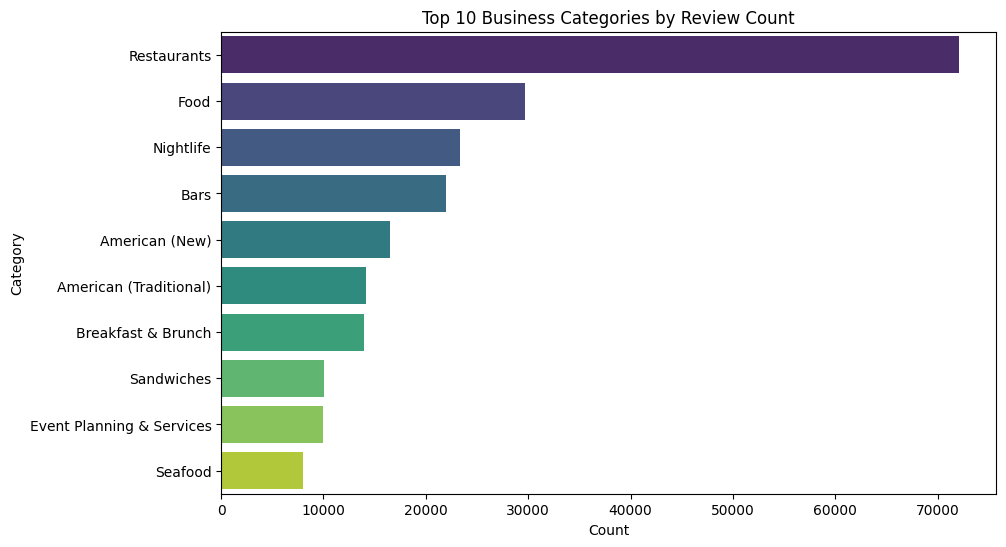

In [ ]:
from collections import Counter

categories = data['categories'].dropna().str.split(', ')
category_counts = Counter([cat for sublist in categories for cat in sublist])

category_df = pd.DataFrame(category_counts.items(), columns=['Category', 'Count']).sort_values(by='Count', ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=category_df, x='Count', y='Category', palette='viridis')
plt.title('Top 10 Business Categories by Review Count')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


Step 5: Sentiment Distribution

Use the star ratings to define sentiment labels:

1-2 stars: Negative
3 stars: Neutral
4-5 stars: Positive

<ipython-input-26-834c0b4c32e1>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment', palette='coolwarm')


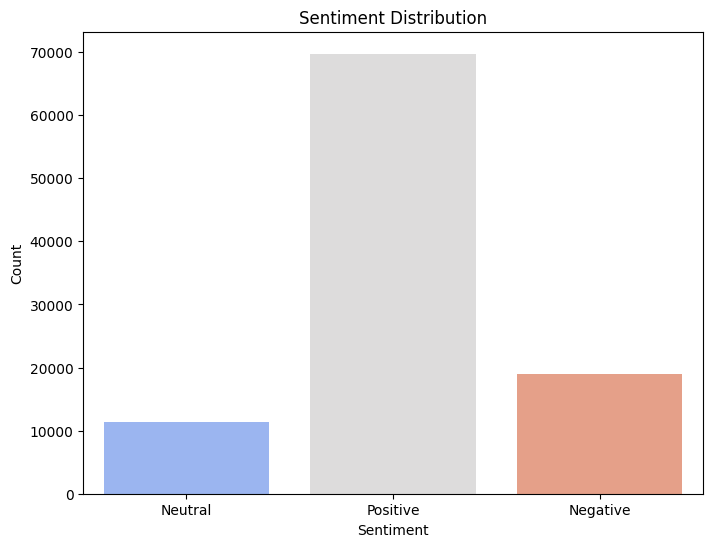

In [ ]:
def assign_sentiment(stars):
    if stars <= 2:
        return 'Negative'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Positive'

data['sentiment'] = data['stars'].apply(assign_sentiment)

plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='sentiment', palette='coolwarm')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


Step 6: Relationship Between Check-Ins and Ratings

   checkin_count     stars
0            0.0  3.833340
1            1.0  3.846028


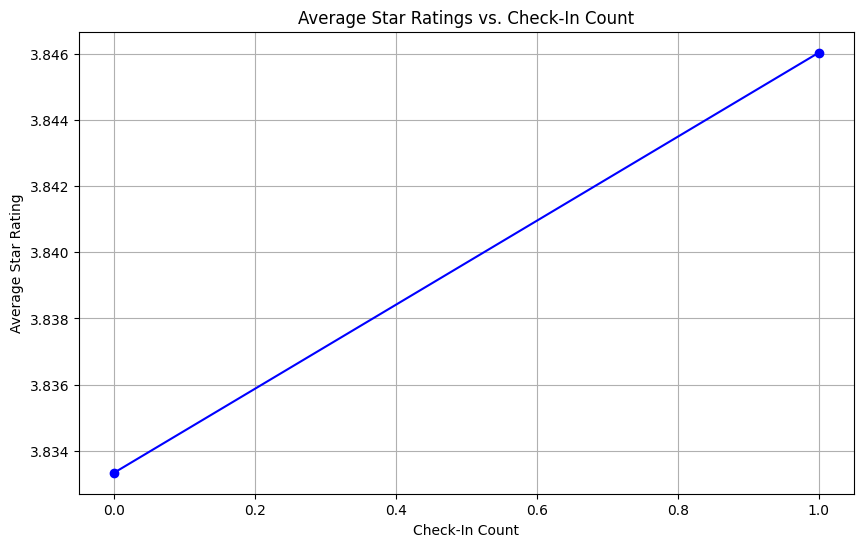

In [ ]:
aggregated_data = data.groupby('checkin_count').agg({'stars': 'mean'}).reset_index()
print(aggregated_data.head())

bins = [0, 5, 10, 20, 50, 100, 200, 500, 1000]  # Define bins
labels = ['0-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501+']
data['checkin_range'] = pd.cut(data['checkin_count'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
plt.plot(aggregated_data['checkin_count'], aggregated_data['stars'], marker='o', linestyle='-', color='b')
plt.title('Average Star Ratings vs. Check-In Count')
plt.xlabel('Check-In Count')
plt.ylabel('Average Star Rating')
plt.grid(True)
plt.show()




Step 7: Top Words in Positive and Negative Reviews

Extract Positive and Negative Reviews

In [ ]:
pip install wordcloud

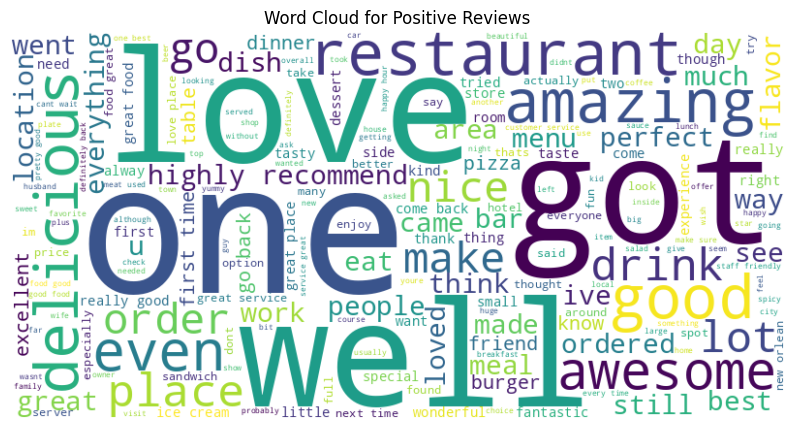

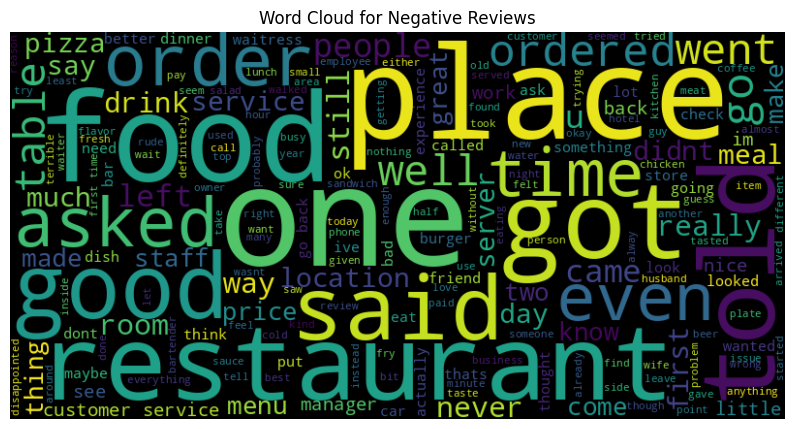

In [ ]:
from wordcloud import WordCloud

positive_text = ' '.join(data[data['sentiment'] == 'Positive']['cleaned_text'].dropna().astype(str))
negative_text = ' '.join(data[data['sentiment'] == 'Negative']['cleaned_text'].dropna().astype(str))

positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wc = WordCloud(width=800, height=400, background_color='black').generate(negative_text)

plt.figure(figsize=(10, 6))
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

plt.figure(figsize=(10, 6))
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()


Step 8: Correlation Analysis

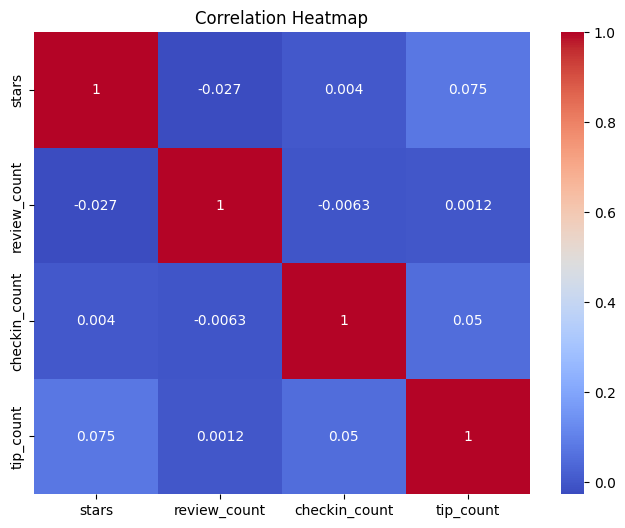

In [ ]:
# Correlation heatmap for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(data[['stars', 'review_count', 'checkin_count', 'tip_count']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


Step 9: Save EDA Report

In [ ]:
# Save EDA-ready dataset
data.to_csv('eda_ready_data.csv', index=False)


# Module 4 Sentiment Analysis Modeling

Step 1: Load the Preprocessed Dataset

In [ ]:
import pandas as pd

# Load the preprocessed dataset
data = pd.read_csv('preprocessed_data.csv')
print(data.head())


                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  BiTunyQ73aT9WBnpR9DZGw  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ   
2  saUsX_uimxRlCVr67Z4Jig  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A   
3  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
4  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   

                                        cleaned_text  stars  \
0  decide eat aware going take 2 hour beginning e...      3   
1  ive taken lot spin class year nothing compare ...      5   
2  family diner buffet eclectic assortment large ...      3   
3  wow yummy different delicious favorite lamb cu...      5   
4  cute interior owner gave u tour upcoming patio...      4   

                                          categories  average_stars  \
0  Restaurants, Breakfast & Brunch, Food, Juice B...            NaN   
1  Active Life, 

Step 2: Create Sentiment Labels
Define the sentiment labels:
Positive: stars >= 4
Neutral: stars == 3
Negative: stars <= 2

In [ ]:
def assign_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Negative'

data['sentiment'] = data['stars'].apply(assign_sentiment)
print(data['sentiment'].value_counts())


sentiment
Positive    69729
Negative    18909
Neutral     11362
Name: count, dtype: int64


Step 3: Split Data into Train and Test Sets
Use the cleaned_text as the feature (X) and sentiment as the target (y).

In [ ]:
from sklearn.model_selection import train_test_split

# Features and target
X = data['cleaned_text']
y = data['sentiment']

# Initial split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Combine and drop NaNs for train set
train_df = pd.DataFrame({'text': X_train, 'label': y_train}).dropna(subset=['text'])
X_train = train_df['text'].astype(str)
y_train = train_df['label']

# Combine and drop NaNs for test set
test_df = pd.DataFrame({'text': X_test, 'label': y_test}).dropna(subset=['text'])
X_test = test_df['text'].astype(str)
y_test = test_df['label']

print("Train Set Size:", X_train.shape[0])
print("Test Set Size:", X_test.shape[0])


Train Set Size: 79998
Test Set Size: 20000


Step 4: Vectorize the Text Data
Convert the cleaned_text into numerical format using TF-IDF Vectorizer.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 3), min_df=0.01, max_df=0.5)

# Transform training and testing data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Transformation Complete!")
print("Shape of X_train:", X_train_tfidf.shape)
print("Shape of X_test:", X_test_tfidf.shape)


TF-IDF Transformation Complete!
Shape of X_train: (79998, 889)
Shape of X_test: (20000, 889)


1. Multinomial Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Train the model using Multinomial Logistic Regression
# Ensure the 'multi_class' parameter is set to 'multinomial' and choose an appropriate solver that supports it, such as 'lbfgs'
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')

# Fit the model on the training data
lr_model.fit(X_train_tfidf, y_train)

# Predict on the test data
y_pred = lr_model.predict(X_test_tfidf)

# Evaluate the model using classification report and confusion matrix
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
               precision    recall  f1-score   support

    Negative       0.77      0.78      0.77      3762
     Neutral       0.54      0.27      0.36      2275
    Positive       0.88      0.95      0.92     13963

    accuracy                           0.84     20000
   macro avg       0.73      0.67      0.68     20000
weighted avg       0.82      0.84      0.83     20000

Confusion Matrix:
 [[ 2919   235   608]
 [  531   605  1139]
 [  353   281 13329]]


Save the model

In [ ]:
import joblib

# Save the model
joblib.dump(lr_model, 'best_sentiment_model.pkl')
print("Best model saved successfully!")


Best model saved successfully!


Step 10: Analyze Results
Visualize the confusion matrix to understand model performance:

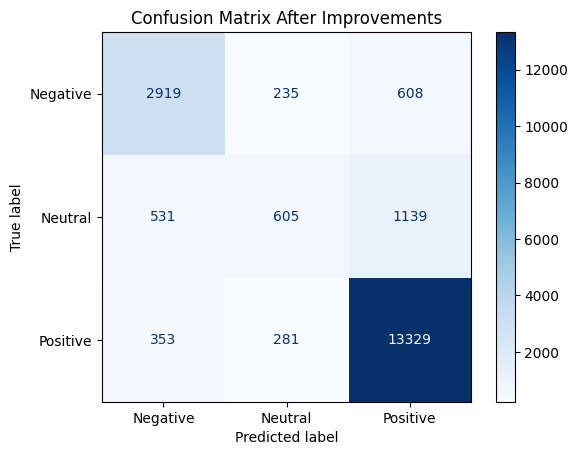

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title("Confusion Matrix After Improvements")
plt.show()


# Module 5

Model Fitting: Train your chosen model(s) using the training data

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


model = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial', solver='lbfgs')
model.fit(X_train_tfidf, y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       0.77      0.78      0.77      3762
     Neutral       0.54      0.27      0.36      2275
    Positive       0.88      0.95      0.92     13963

    accuracy                           0.84     20000
   macro avg       0.73      0.67      0.68     20000
weighted avg       0.82      0.84      0.83     20000

Confusion Matrix:
 [[ 2919   235   608]
 [  531   605  1139]
 [  353   281 13329]]


Step 1: Save the Trained Model

In [ ]:
import joblib

# Save the trained model to disk
joblib.dump(lr_model, 'final_sentiment_model.pkl')


['final_sentiment_model.pkl']

Step 2: Save the TF-IDF Vectorizer

In [ ]:
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')


['tfidf_vectorizer.pkl']

Step 3: Create a Prediction Function

In [ ]:
def predict_sentiment(text):
    # Load the trained model and the vectorizer
    model = joblib.load('final_sentiment_model.pkl')
    vectorizer = joblib.load('tfidf_vectorizer.pkl')

    # Transform the input text using the loaded vectorizer
    text_tfidf = vectorizer.transform([text])

    # Use the loaded model to predict the sentiment
    prediction = model.predict(text_tfidf)
    return prediction


Step 4: Implement a Simple User Interaction Script

In [ ]:
# Example of using the prediction function in an interactive session
# user_input = input("Enter a review to analyze sentiment: ")
# predicted_sentiment = predict_sentiment(user_input)
# print(f"The predicted sentiment for the review is: {predicted_sentiment[0]}")


# Module 6: Pattern Mining and Similarity Graphs

In [ ]:
import pandas as pd

df = pd.read_csv("preprocessed_data.csv")
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

token_lists = df['cleaned_text'].apply(lambda x: list(set(x.split())))
df_tokenized = pd.DataFrame({"tokens": token_lists})


FP-Growth + Association Rules

In [ ]:
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Sample 10k reviews for FP-Growth
df_sampled = df_tokenized.sample(n=1000, random_state=42)

te = TransactionEncoder()
te_array = te.fit(df_sampled['tokens']).transform(df_sampled['tokens'])
te_df = pd.DataFrame(te_array, columns=te.columns_)

# Step 1: Get frequent itemsets
freq_itemsets = fpgrowth(te_df, min_support=0.02, use_colnames=True)

# Step 2: Get association rules first (requires itemsets to still be frozenset)
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.5)

# Step 3: After association_rules is done, now clean for export/display
freq_itemsets['itemsets'] = freq_itemsets['itemsets'].apply(lambda x: ', '.join(sorted(x)))
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

# Save to CSV
freq_itemsets.to_csv("freq_itemsets_final.csv", index=False)
rules.to_csv("assoc_rules_csv_final.csv", index=False)



Jaccard Similarity (Top Word Pairs)

In [ ]:
from itertools import combinations
from collections import Counter

pair_counts = Counter()
word_counts = Counter()

for tokens in df_tokenized['tokens']:
    word_counts.update(tokens)
    pair_counts.update(combinations(sorted(tokens), 2))

jaccard_data = []
for (w1, w2), inter in pair_counts.items():
    union = word_counts[w1] + word_counts[w2] - inter
    jaccard_data.append((w1, w2, inter / union))

jaccard_df = pd.DataFrame(jaccard_data, columns=['word1', 'word2', 'jaccard'])
jaccard_df = jaccard_df.sort_values(by='jaccard', ascending=False).head(100)
jaccard_df.to_csv("jaccard_similarity_top.csv", index=False)


MinHash LSH for Similar Reviews

In [ ]:
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics.pairwise import pairwise_distances
import pandas as pd

vectorizer = HashingVectorizer(analyzer='word', n_features=2**12, norm=None, alternate_sign=False)
X = vectorizer.transform(df["cleaned_text"])

# Sample for performance
sample_idx = df.sample(n=100, random_state=42).index
X_sampled = X[sample_idx]

# Convert sparse matrix to dense
X_dense = X_sampled.toarray()

# Compute Hamming distance (proxy for Jaccard on binary)
dist_matrix = pairwise_distances(X_dense, metric="hamming")

# Save to CSV
similarity_df = pd.DataFrame(dist_matrix)
similarity_df.to_csv("minhash_lsh_approx_similarity.csv", index=False)

print("Similarity matrix saved.")


Similarity matrix saved.


Co-Occurrence Graph Data for Streamlit

In [ ]:
import pandas as pd
import networkx as nx
from itertools import combinations
from collections import Counter

# Load cleaned data
df = pd.read_csv("preprocessed_data.csv")
df = df.dropna(subset=['cleaned_text'])
df = df[df['cleaned_text'].str.strip() != '']

# Tokenize: keep unique words per review
token_lists = df['cleaned_text'].apply(lambda x: list(set(x.split())))

# Count co-occurring word pairs
pair_counts = Counter()
for tokens in token_lists:
    pair_counts.update(combinations(sorted(tokens), 2))

# Filter only strong co-occurrence pairs
min_freq = 1500
filtered_pairs = {pair: count for pair, count in pair_counts.items() if count >= min_freq}

# Prepare edge dataframe
edges_df = pd.DataFrame(
    [(w1, w2, freq) for (w1, w2), freq in filtered_pairs.items()],
    columns=["source", "target", "weight"]
)

# Save for Streamlit visualization
edges_df.to_csv("cooccurrence_graph_edges.csv", index=False)
print("cooccurrence_graph_edges.csv saved with", len(edges_df), "edges.")


cooccurrence_graph_edges.csv saved with 3894 edges.
